In [1]:
!pip install -q segmentation-models-pytorch 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.8 MB/s eta 0:00:00


In [2]:
import os
import gc
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import albumentations as A
import segmentation_models_pytorch as smp
from albumentations.pytorch import ToTensorV2 

In [3]:
# ==========================================
# 1. КОНФИГУРАЦИЯ И НАСТРОЙКИ
# ==========================================
TEST_IMAGES_DIR = Path(r"/kaggle/input/competitions/dl-lab-3-product-segmentation/test_images")

# Базовая папка, где лежат все твои датасеты с весами
BASE_DATASETS_DIR = Path(r"/kaggle/input/datasets/tkachenko1van/conf3-deeplab-convnext-fold1-finetuned")

IMG_SIZE = 320
THRESHOLD = 0.45
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [4]:
# ==========================================
# 2. ПОСТПРОЦЕССИНГ И ИНФЕРЕНС
# ==========================================
def postprocess_mask(mask: np.ndarray) -> np.ndarray:
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest_label).astype(np.uint8)
    else:
        return np.zeros_like(mask) 
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cv2.drawContours(mask, contours, -1, 1, thickness=cv2.FILLED)
        
    return mask

def serialize_mask(mask2d: np.ndarray) -> str:
    return json.dumps(mask2d.tolist(), separators=(",", ":")) 

def predict_image(image_bgr: np.ndarray, models: list, threshold=THRESHOLD) -> np.ndarray:
    original_h, original_w = image_bgr.shape[:2]
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    augmented = val_transform(image=image_rgb)
    img_orig = augmented['image'].unsqueeze(0).to(DEVICE)

    img_h  = torch.flip(img_orig, dims=[3])
    img_v  = torch.flip(img_orig, dims=[2])
    img_hv = torch.flip(img_orig, dims=[2, 3])

    ensemble_probs = torch.zeros((1, 1, IMG_SIZE, IMG_SIZE), device=DEVICE)
    total_predictions = len(models) * 4 
    
    for model in models:
        with torch.amp.autocast('cuda'):
            prob_orig = torch.sigmoid(model(img_orig))
            prob_h = torch.sigmoid(model(img_h))
            prob_h_inv = torch.flip(prob_h, dims=[3])
            prob_v = torch.sigmoid(model(img_v))
            prob_v_inv = torch.flip(prob_v, dims=[2])
            prob_hv = torch.sigmoid(model(img_hv))
            prob_hv_inv = torch.flip(prob_hv, dims=[2, 3])
            
            ensemble_probs += (prob_orig + prob_h_inv + prob_v_inv + prob_hv_inv)
            
    ensemble_probs /= total_predictions
    probs_np = ensemble_probs[0, 0].cpu().numpy().astype(np.float32)
    
    if probs_np.shape != (original_h, original_w):
        probs_np = cv2.resize(probs_np, (original_w, original_h), interpolation=cv2.INTER_LINEAR)
        
    binary_mask = (probs_np > threshold).astype(np.uint8)
    final_mask = postprocess_mask(binary_mask)
    
    return final_mask 

📸 Найдено тестовых изображений: 2000

🚀 СТАРТ ОБРАБОТКИ: FINETUNED MODELS
✅ Загружено моделей (finetuned): 5


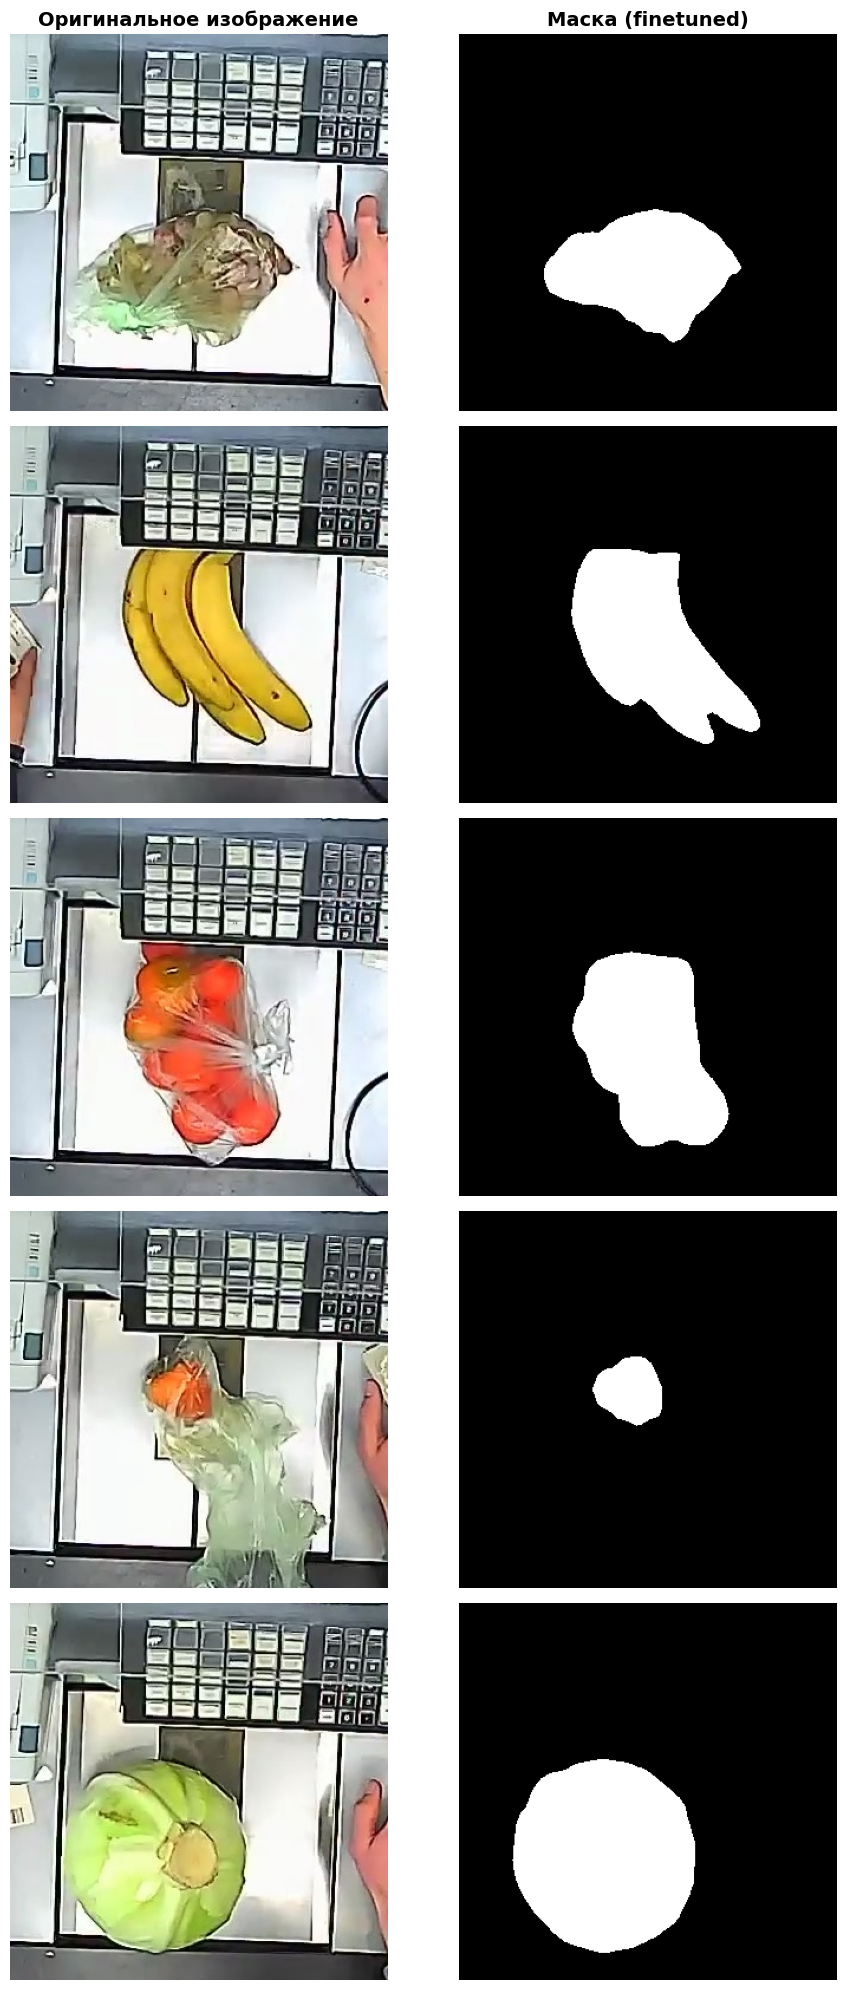

Инференс finetuned: 100%|██████████| 2000/2000 [11:09<00:00,  2.99it/s]


🎉 Готово! Сабмит сохранен в: submission_conf3_finetuned.csv

🚀 СТАРТ ОБРАБОТКИ: BLENDED MODELS
✅ Загружено моделей (blended): 5


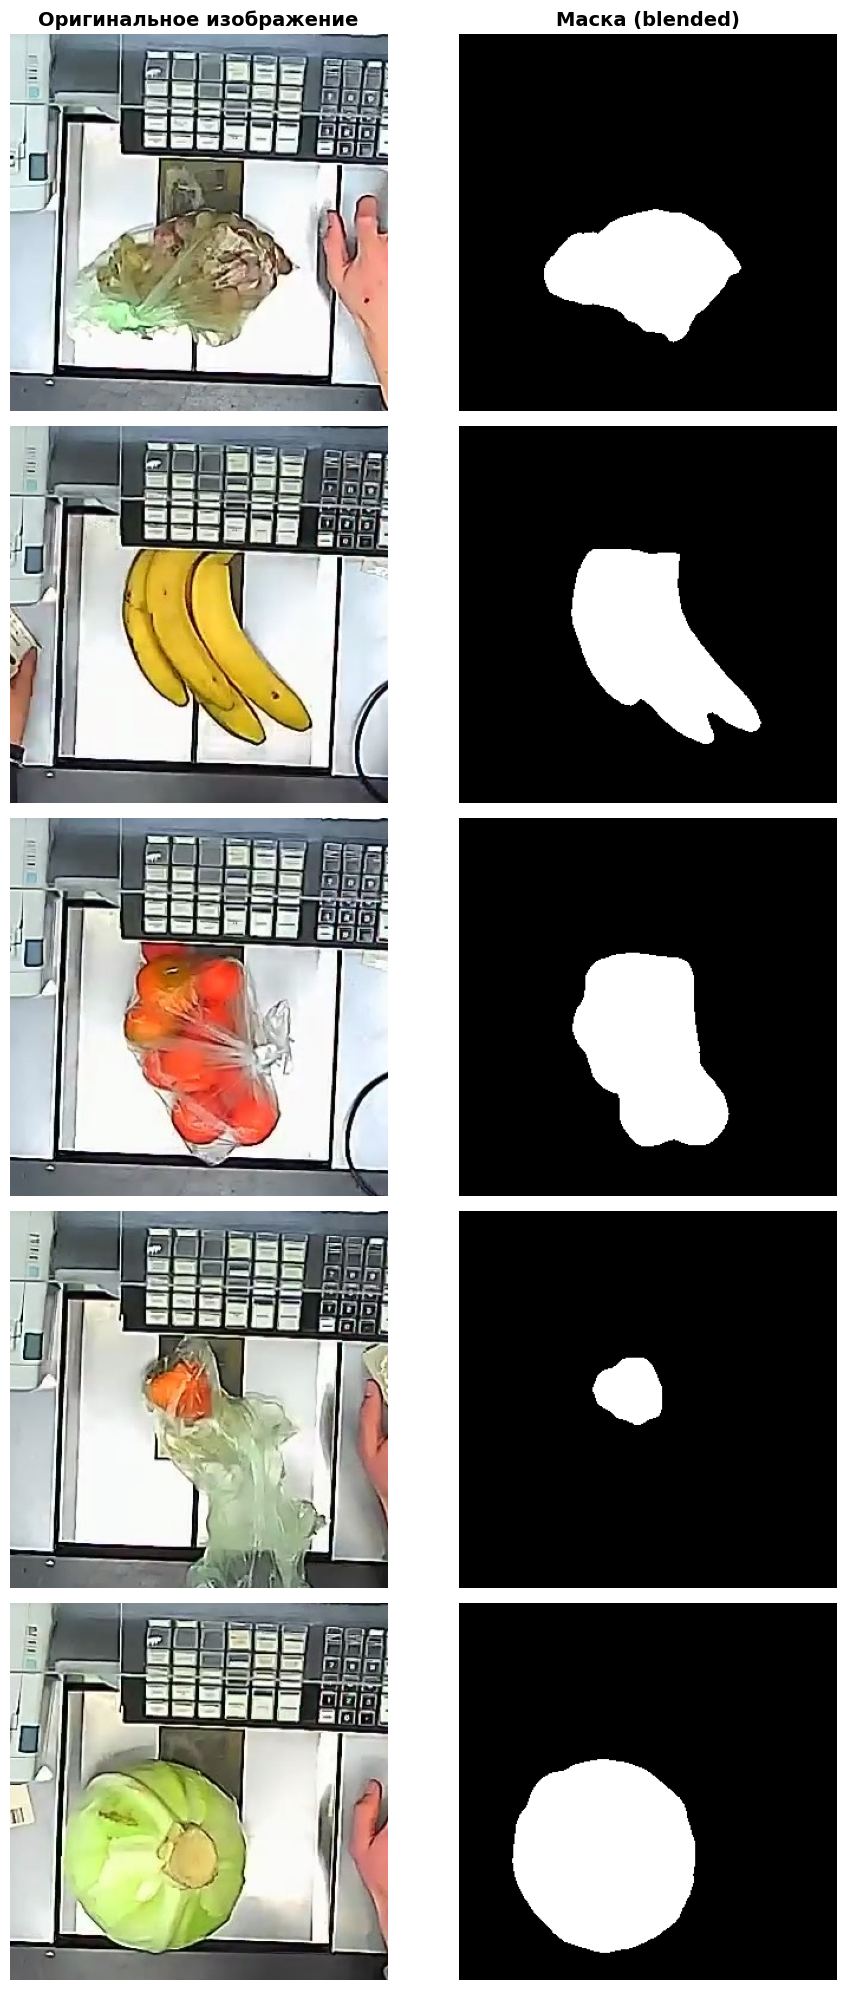

Инференс blended: 100%|██████████| 2000/2000 [10:58<00:00,  3.04it/s]


🎉 Готово! Сабмит сохранен в: submission_conf3_blended.csv



In [5]:
# ==========================================
# 3. ГЛАВНЫЙ ЦИКЛ (FINETUNED -> BLENDED)
# ==========================================
image_paths = sorted(list(TEST_IMAGES_DIR.glob("*.jpg"))) + sorted(list(TEST_IMAGES_DIR.glob("*.png")))
print(f"📸 Найдено тестовых изображений: {len(image_paths)}\n")

weight_types = ["finetuned", "blended"]

for w_type in weight_types:
    print(f"{'='*50}\n🚀 СТАРТ ОБРАБОТКИ: {w_type.upper()} MODELS\n{'='*50}")
    
    models = []
    
    # 1. Загрузка 5 фолдов
    for fold in range(1, 6):
        weight_path = BASE_DATASETS_DIR / f"conf3_deeplab_convnext_fold{fold}_{w_type}.pth"
        
        if weight_path is None or not weight_path.exists():
            print(f"⚠️ Файл не найден: {target_filename}")
            continue
            
        model = smp.DeepLabV3Plus(encoder_name="tu-convnext_small", encoder_weights=None, in_channels=3, classes=1)
        model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        models.append(model)
        
    print(f"✅ Загружено моделей ({w_type}): {len(models)}")
    
    if len(models) == 0:
        print("Пропуск шага из-за отсутствия моделей.")
        continue

    # 2. Визуальная проверка
    sample_paths = image_paths[:5]
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 20))

    axes[0, 0].set_title("Оригинальное изображение", fontsize=14, fontweight='bold')
    axes[0, 1].set_title(f"Маска ({w_type})", fontsize=14, fontweight='bold')

    for ax in axes.flatten():
        ax.axis('off')

    with torch.inference_mode():
        for i, img_path in enumerate(sample_paths):
            img_bgr = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            mask = predict_image(img_bgr, models)

            axes[i, 0].imshow(img_rgb)
            axes[i, 1].imshow(mask, cmap='gray')

    plt.tight_layout()
    plt.show() 

    # 3. Инференс и Сабмит
    submission_data = []
    output_csv = f"submission_conf3_{w_type}.csv"

    with torch.inference_mode():
        for img_path in tqdm(image_paths, desc=f"Инференс {w_type}"):
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None:
                continue

            final_mask = predict_image(img_bgr, models)

            submission_data.append({
                "ImageId": img_path.name,
                "mask": serialize_mask(final_mask),
            })

    submission_df = pd.DataFrame(submission_data)
    submission_df.to_csv(output_csv, index=False, encoding="utf-8")
    print(f"🎉 Готово! Сабмит сохранен в: {output_csv}\n")
    
    # 4. Очистка памяти перед загрузкой следующих моделей
    del models
    gc.collect()
    torch.cuda.empty_cache()